In [ ]:
# From he5 To GeoTIFF: https://github.com/martinrapilly/PRISMA2GeoTIFF/blob/main/PRISMA2GeoTIFF.ipynb
# From he5 To ENVI: https://rdrr.io/github/lbusett/prismaread/f/vignettes/prismaread_vignette.Rmd
# https://github.com/IREA-CNR-MI/prismaread/tree/master

In [2]:
import h5py
import numpy as np

In [ ]:
file = h5py.File(
    "./PRISMA/method_valid/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001.he5",
    "r",
)


def print_structure(name):
    print(name)


file.visit(print_structure)
file

HDFEOS
HDFEOS/ADDITIONAL
HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
HDFEOS/SWATHS
HDFEOS/SWATHS/PRS_L1_HCO
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/Cloud_Mask
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/FrameNumber
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/LandCover_Mask
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/SWIR_Cube
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/SWIR_PIXEL_SAT_ERR_MATRIX
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/SunGlint_Mask
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/VNIR_Cube
HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/VNIR_PIXEL_SAT_ERR_MATRIX
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields/Latitude_SWIR
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields/Latitude_VNIR
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields/Longitude_SWIR
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields/Longitude_VNIR
HDFEOS/SWATHS/PRS_L1_HCO/Geolocation Fields/Time
HDFEOS/SWATHS/PRS_L1_HRC
HDFEOS/SWATHS/PRS_L1_HRC/Data Fields
HDFEOS/SWATHS/PRS_L1_HRC/Data Fields/FrameNumber
HDFEOS/

<HDF5 file "PRS_L1_STD_OFFL_20210209072220_20210209072224_0001.he5" (mode r)>

In [ ]:
# Read VNIR radiance
vnir = file["/HDFEOS/SWATHS/PRS_L1_HRC/Data Fields/VNIR_Cube"][:]
swir = file["/HDFEOS/SWATHS/PRS_L1_HRC/Data Fields/SWIR_Cube"][:]
vnir.shape, swir.shape
# 1000 row: high
# 66: bands
# 1000 col: width

((1000, 66, 1000), (1000, 173, 1000))

In [ ]:
vnir_wavelengths = file["KDP_AUX/Cw_Vnir_Matrix"][()]
swir_wavelengths = file["KDP_AUX/Cw_Swir_Matrix"][()]
vnir_wavelengths.shape, swir_wavelengths.shape

((1000, 256), (1000, 256))

In [ ]:
file["KDP_AUX/Fwhm_Swir_Matrix"][()][0], swir_wavelengths[0]

In [34]:
sum(vnir_wavelengths[0] > 0), sum(swir_wavelengths[1] > 0), sum(
    np.mean(swir_wavelengths, axis=0) > 0
)

(63, 171, 171)

In [ ]:
# Generate*.hdr file

# Load HE5 file
he5_path = "./Project2/PRISMA/method_valid/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001.he5"

with h5py.File(he5_path, "r") as f:
    # SWIR data path: load data dimension
    swir_data = f["/HDFEOS/SWATHS/PRS_L1_HCO/Data Fields/SWIR_Cube"]
    lines, bands, samples = swir_data.shape  # (1000, 173, 1000)

    # Band matrics
    swir_wavelengths = f["/KDP_AUX/Cw_Swir_Matrix"][:]  # shape: (1000, 256)
    avg_wavelengths = np.mean(swir_wavelengths, axis=0)  # shape: (256,)
    valid_mask = avg_wavelengths > 0
    valid_wavelengths = avg_wavelengths[valid_mask]  # shape: (171,)
    valid_wavelengths = np.append(valid_wavelengths, [920, 930])  # shape: (173,)

# Write ENVI .hdr file
hdr_path = "prisma.hdr"
with open(hdr_path, "w") as f:
    f.write("ENVI\n")
    f.write("description = {[PRISMA L1 - CH4 PLUME ENMAP MATCHED - REFLECTANCE]}\n")
    f.write(f"samples = {samples}\n")
    f.write(f"lines   = {lines}\n")
    f.write(f"bands   = {bands}\n")
    f.write("header offset = 0\n")
    f.write("file type = ENVI Standard\n")
    f.write("data type = 4\n")  # float32
    f.write("interleave = bsq\n")
    f.write("sensor type = PRISMA\n")
    f.write("byte order = 0\n")
    f.write("wavelength units = Nanometers\n")

    # Write list
    wl_str = ", ".join([f"{w:.2f}" for w in valid_wavelengths])
    f.write(f"wavelength = {{ {wl_str} }}\n")

In [ ]:
import spectral

rdn = "./PRISMA/method_valid/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001_HCO_SWIR"
rdn_file = spectral.io.envi.open(rdn + ".hdr", image=rdn + ".envi")
rdn_file_memmap = rdn_file.open_memmap(interleave="bip", writable=False)

In [2]:
rdn_file_memmap.shape

(1240, 1238, 171)

In [ ]:
with open("./prisma_all_wavelengths.txt", "r", encoding="utf-8") as f:
    text = f.read()

text = text.replace(" \n", "")

lines = text.splitlines()
lines = [line for line in lines if line.strip() != ""]

with open("prisma_all_wavelengths.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

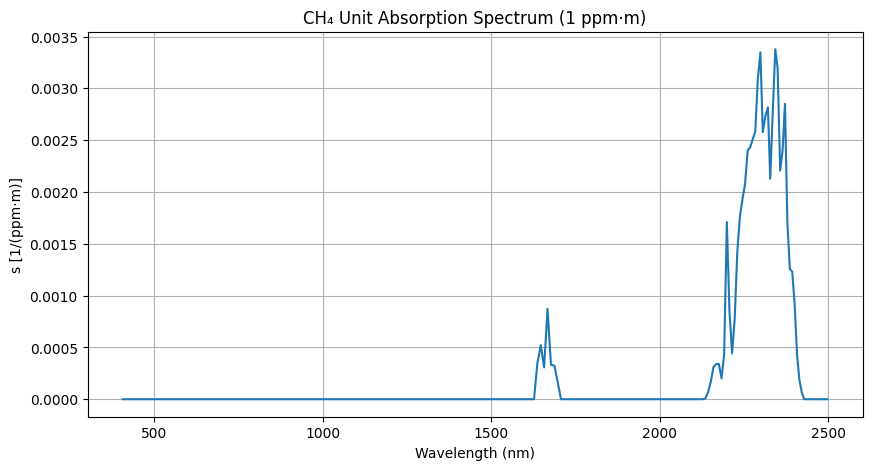

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# data = np.loadtxt('target_spectrum_swir.txt')
data = np.loadtxt("target_spectrum_all.txt")
wavelengths = data[:, 0]
spectrum = data[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, spectrum)
plt.title("CH₄ Unit Absorption Spectrum (1 ppm·m)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("s [1/(ppm·m)]")
plt.grid(True)
plt.show()

#### Reproduce
###### https://amt.copernicus.org/articles/16/2627/2023/amt-16-2627-2023.pdf

In [ ]:
import spectral

# rdn='./Project2/code/mag1c/output/PRS_L1_STD_OFFL_20210622071436_20210622071440_0001_all' #√
# rdn='./Project2/code/mag1c/output/PRS_L1_STD_OFFL_20210209072220_20210209072224_0001_all'  # Not clear
rdn = "./Project4/code/mag1c/output/PRS_L1_STD_OFFL_20200721072426_20200721072430_0001_all"  # √
rdn_file = spectral.io.envi.open(rdn + ".hdr")
rdn_file_memmap = rdn_file.open_memmap(interleave="bip", writable=False)

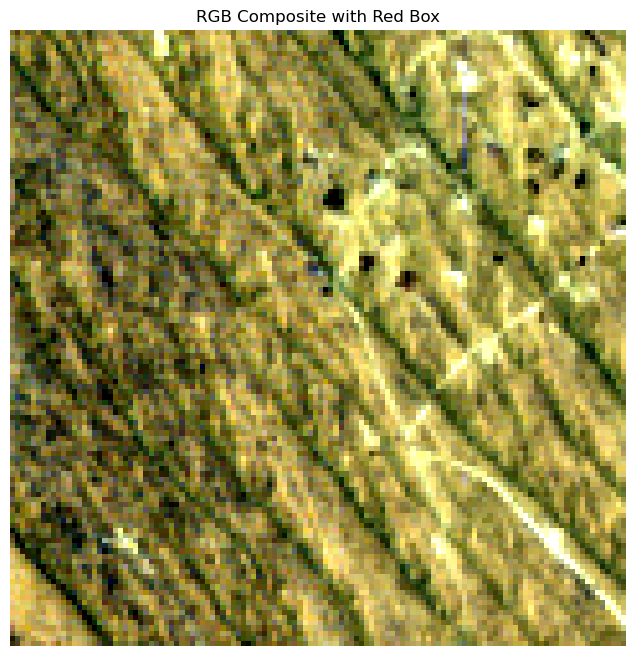

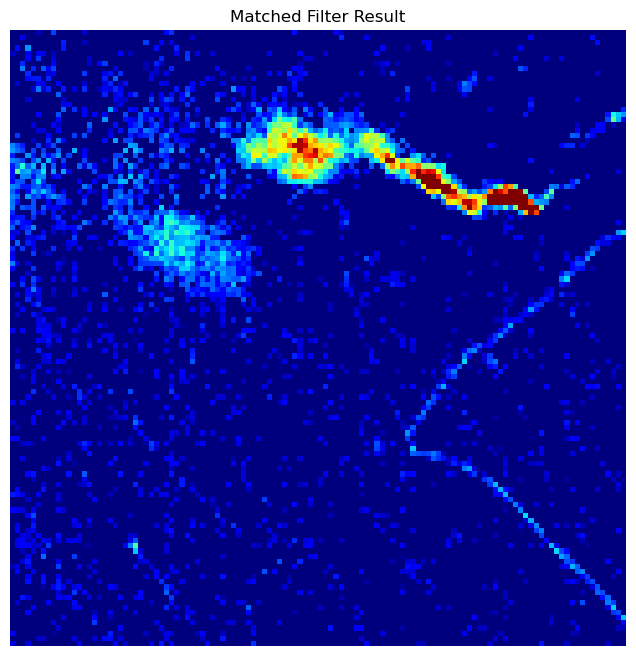

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

data = np.rot90(rdn_file_memmap, k=-1, axes=(0, 1))
data = data[280:400, 310:430, :]
# data = data[280:390, 351:461, :]
# data = data[449:559, 372:482, :]
# data = rdn_file_memmap
# shape: (height, width, bands)

rgb = data[:, :, 0:3]


def normalize(img):
    img_min = np.percentile(img, 2)
    img_max = np.percentile(img, 98)
    img_clipped = np.clip(img, img_min, img_max)
    return (img_clipped - img_min) / (img_max - img_min)


rgb_norm = normalize(rgb)

center_x, center_y = 420, 314  # 432, 489 # 411, 320
# center_x, center_y = 314,412
box_size = 200
top_left_x = center_x - box_size // 2
top_left_y = center_y - box_size // 2

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_norm)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(rect)
ax.set_title("RGB Composite with Red Box")
ax.axis("off")
plt.show()

ppm = data[:, :, 3]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ppm, cmap="jet", vmin=0, vmax=10000)
rect = patches.Rectangle(
    (top_left_x, top_left_y),
    box_size,
    box_size,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(rect)
# plt.colorbar(im, ax=ax, label='Matched Filter Results (ppm m)')
# ax.set_title("PPM m Band with Red Box")
ax.set_title("Matched Filter Result")
ax.axis("off")
plt.show()

### Validation with Airborne

In [ ]:
rdn = "./Project2/code/mag1c/output/PRS_L1_STD_OFFL_20210206031837_20210206031842_0001_all"  # √
rdn_file = spectral.io.envi.open(rdn + ".hdr")
rdn_file_memmap = rdn_file.open_memmap(interleave="bip", writable=False)

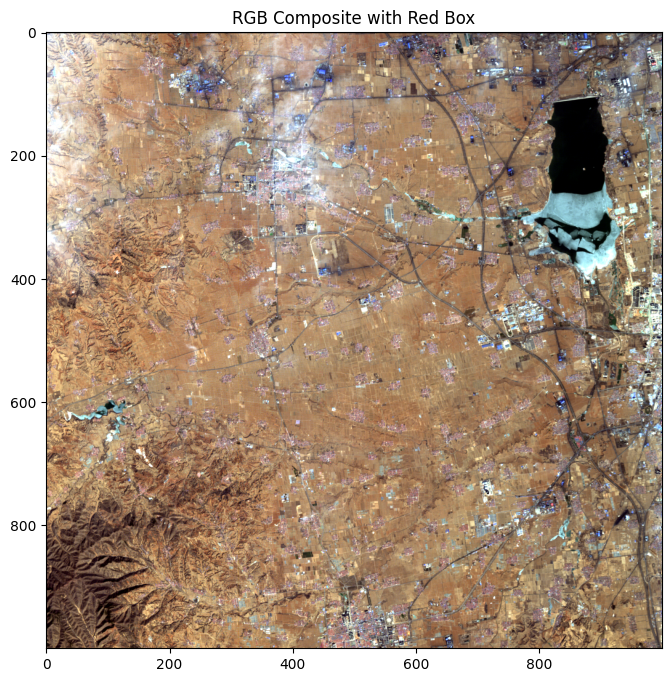

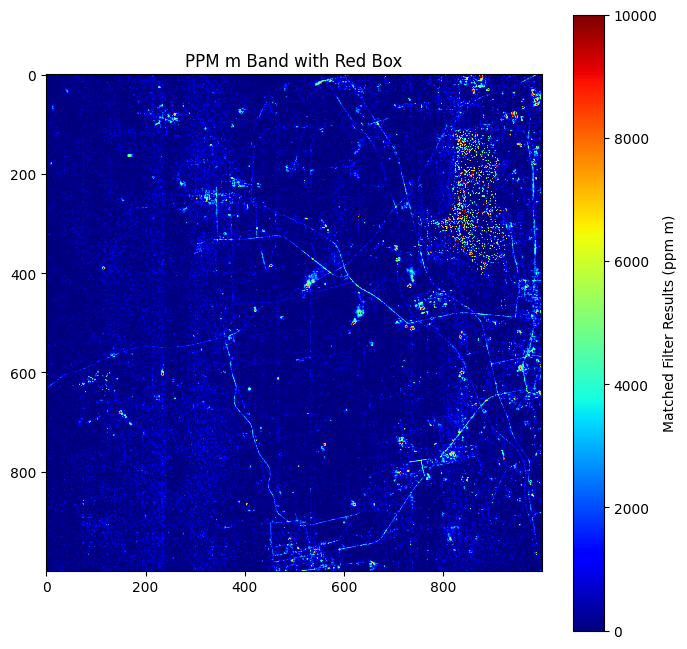

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

data = np.rot90(rdn_file_memmap, k=-1, axes=(0, 1))
# data = rdn_file_memmap
# data = data[400:600, 500:700, :]
# data = data[400:600, 550:750, :]
# data = data[350:500, 650:800, :]
# data = data[700:900, 300:500, :] #water
# data = data[600:800, 450:650, :]
# data = data[0:200, 500:700, :]

rgb = data[:, :, 0:3]


def normalize_per_band(img):
    norm = np.zeros_like(img, dtype=np.float32)
    for i in range(img.shape[2]):
        band = img[:, :, i]
        band_min = np.percentile(band, 1)
        band_max = np.percentile(band, 99)
        norm[:, :, i] = np.clip((band - band_min) / (band_max - band_min), 0, 1)
    return norm


rgb_norm = normalize_per_band(rgb)


center_x, center_y = 400, 800
# center_x, center_y = 314,412
box_size = 200
top_left_x = center_x - box_size // 2
top_left_y = center_y - box_size // 2

fig, ax = plt.subplots(figsize=(8, 8))
# ax.set_xlim(0, 1000)
# ax.set_ylim(0, 1000)
ax.imshow(rgb_norm)
# rect = patches.Rectangle(
#     (top_left_x, top_left_y),
#     box_size, box_size,
#     linewidth=2,
#     edgecolor='red',
#     facecolor='none'
# )
# ax.add_patch(rect)
ax.set_title("RGB Composite with Red Box")
# plt.grid(True)
# ax.axis('off')
plt.show()

ppm = data[:, :, 3]

fig, ax = plt.subplots(figsize=(8, 8))
# ax.set_xlim(0, 1000)
# ax.set_ylim(0, 1000)
im = ax.imshow(ppm, cmap="jet", vmin=0, vmax=10000)
# rect = patches.Rectangle(
#     (top_left_x, top_left_y),
#     box_size, box_size,
#     linewidth=2,
#     edgecolor='red',
#     facecolor='none'
# )
# ax.add_patch(rect)
plt.colorbar(im, ax=ax, label="Matched Filter Results (ppm m)")
# plt.grid(True)
ax.set_title("PPM m Band with Red Box")
# ax.axis('off')
plt.show()

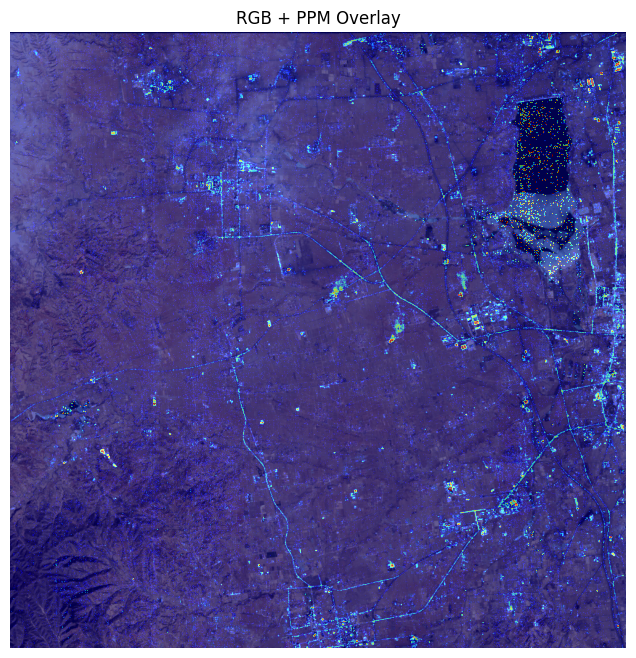

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_norm)

im = ax.imshow(ppm, cmap="jet", alpha=0.6, vmin=0, vmax=10000)
# plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='PPM m')

ax.set_title("RGB + PPM Overlay")
ax.axis("off")
plt.show()